In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
import torch.nn as nn
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Não foi possível encontrar o procedimento especificado'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [7]:
# Configuração visual dos gráficos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (15, 6)

# 1. Carregar os dados
# Altere o nome do arquivo se tiver escolhido outra distribuidora
df = pd.read_csv('AEP_hourly.csv')

# 2. Converter a coluna 'Datetime' para o tipo de dado datetime do Pandas
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 3. ORDENAR PELO TEMPO (Regra de Ouro de Séries Temporais!)
df = df.sort_values('Datetime').reset_index(drop=True)

# Vamos definir a data como o índice do dataframe para facilitar os gráficos
df.set_index('Datetime', inplace=True)

print(f"Tamanho do dataset: {df.shape}")
display(df.head())

Tamanho do dataset: (121273, 1)


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


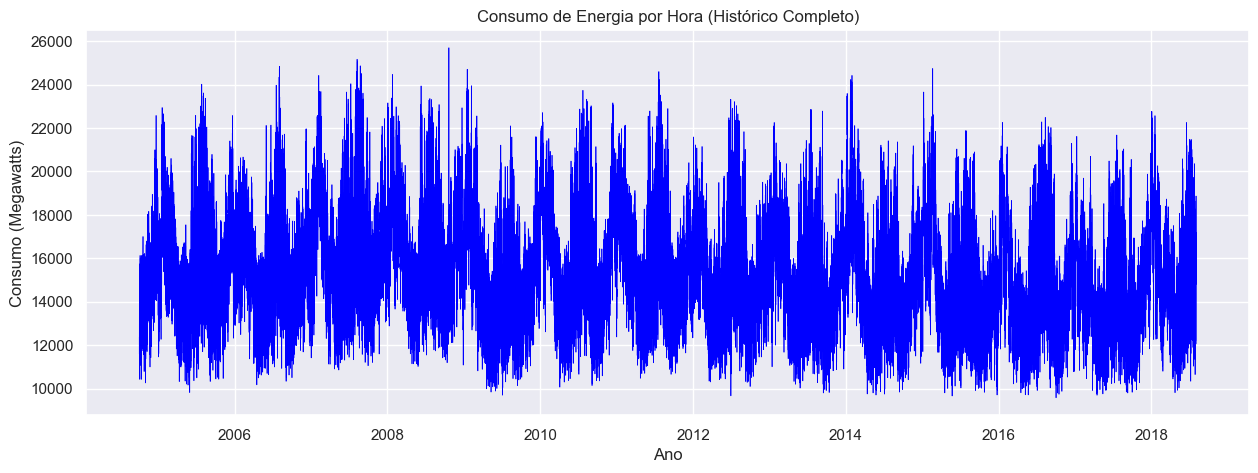

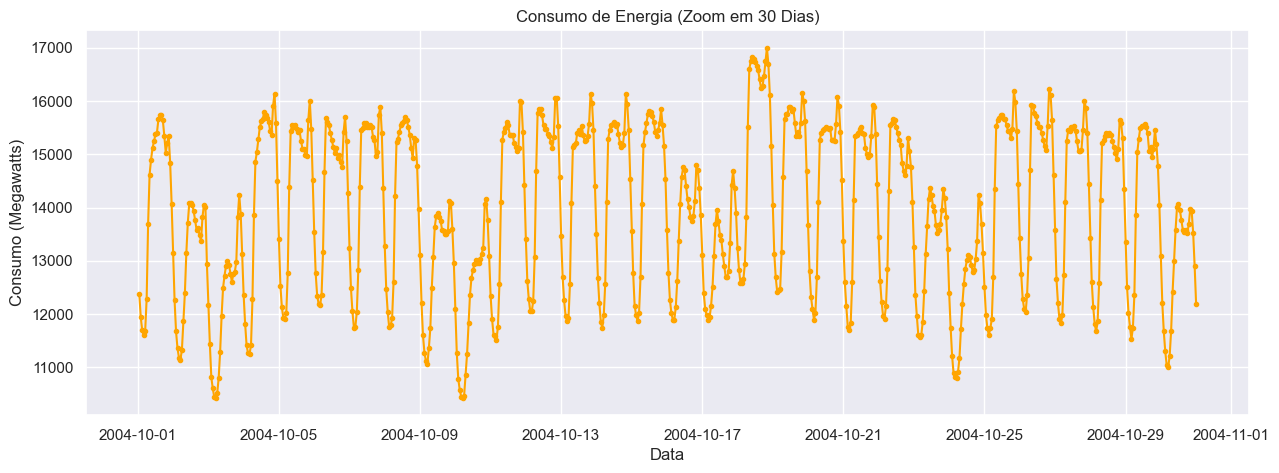

In [8]:
# Gráfico 1: Toda a série temporal (Tendência de longo prazo)
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['AEP_MW'], color='blue', linewidth=0.5)
plt.title('Consumo de Energia por Hora (Histórico Completo)')
plt.xlabel('Ano')
plt.ylabel('Consumo (Megawatts)')
plt.show()

# Gráfico 2: Dando um zoom no primeiro mês de dados (Sazonalidade)
# Isso nos ajudará a ver os picos diários e quedas nos finais de semana
zoom_df = df.iloc[:24*30] # Primeiras 720 horas (30 dias)

plt.figure(figsize=(15, 5))
plt.plot(zoom_df.index, zoom_df['AEP_MW'], color='orange', marker='o', markersize=3)
plt.title('Consumo de Energia (Zoom em 30 Dias)')
plt.xlabel('Data')
plt.ylabel('Consumo (Megawatts)')
plt.show()

In [9]:
# 1. Normalização dos Dados
scaler = MinMaxScaler(feature_range=(0, 1))
dados_escalados = scaler.fit_transform(df[['AEP_MW']])

# 2. Criando a Função da Janela Deslizante
def criar_sequencias(dados, tamanho_janela):
    X, y = [], []
    for i in range(len(dados) - tamanho_janela):
        # Captura as N horas anteriores
        janela_x = dados[i : (i + tamanho_janela), 0]
        # O alvo é a hora imediatamente seguinte
        alvo_y = dados[i + tamanho_janela, 0]
        
        X.append(janela_x)
        y.append(alvo_y)
        
    return np.array(X), np.array(y)

# --- AS MUDANÇAS COMEÇAM AQUI ---

# Nova Janela: 30 dias (30 * 24 = 720 horas)
TAMANHO_JANELA = 720  
X, y = criar_sequencias(dados_escalados, TAMANHO_JANELA)

# 3. Divisão Treino (70%), Validação (15%) e Teste (15%)
# Mantendo a ordem cronológica estrita!
tamanho_total = len(X)
fim_treino = int(tamanho_total * 0.70)
fim_val = int(tamanho_total * 0.85)

# Conjunto de Treinamento (O passado mais distante)
X_treino = X[:fim_treino]
y_treino = y[:fim_treino]

# Conjunto de Validação (O "meio" do tempo, para Early Stopping)
X_val = X[fim_treino:fim_val]
y_val = y[fim_treino:fim_val]

# Conjunto de Teste (O futuro mais recente, totalmente inédito)
X_teste = X[fim_val:]
y_teste = y[fim_val:]

print(f"Total de sequências criadas: {tamanho_total}\n")
print(f"Treino:    X={X_treino.shape}, y={y_treino.shape}")
print(f"Validação: X={X_val.shape}, y={y_val.shape}")
print(f"Teste:     X={X_teste.shape}, y={y_teste.shape}")

Total de sequências criadas: 120553

Treino:    X=(84387, 720), y=(84387,)
Validação: X=(18083, 720), y=(18083,)
Teste:     X=(18083, 720), y=(18083,)


In [ ]:
# --- 1. PREPARAÇÃO DOS DATALOADERS ---

# Convertendo as matrizes Numpy para Tensores do PyTorch
X_treino_t = torch.tensor(X_treino, dtype=torch.float32)
# O .view(-1, 1) garante que o y tenha formato de coluna (N, 1)
y_treino_t = torch.tensor(y_treino, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

X_teste_t = torch.tensor(X_teste, dtype=torch.float32)
y_teste_t = torch.tensor(y_teste, dtype=torch.float32).view(-1, 1)

# Empacotando X e y juntos
dataset_treino = TensorDataset(X_treino_t, y_treino_t)
dataset_val = TensorDataset(X_val_t, y_val_t)
dataset_teste = TensorDataset(X_teste_t, y_teste_t)

# Criando os DataLoaders
# Curiosidade técnica: Embora não possamos embaralhar o tempo ANTES de criar as janelas, 
# podemos embaralhar os lotes (shuffle=True) DURANTE o treino para a rede não viciar!
# Adicionando num_workers para acelerar o carregamento em paralelo
loader_treino = DataLoader(dataset_treino, batch_size=64, shuffle=True, num_workers=4)
loader_val = DataLoader(dataset_val, batch_size=64, shuffle=False, num_workers=4)
loader_teste = DataLoader(dataset_teste, batch_size=64, shuffle=False, num_workers=4)


# --- 2. DEFINIÇÃO DO MODELO (MLP) ---

class PrevisorEnergiaMLP(pl.LightningModule):
    def __init__(self, input_size):
        super().__init__()
        # Arquitetura: Entrada -> 256 -> 64 -> 1
        self.modelo = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout para evitar que decore os dados (overfitting)
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Saída contínua (1 único valor)
        )
        self.lr = 1e-3

    def forward(self, x):
        return self.modelo(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        previsoes = self(x)
        # Em regressão, não usamos CrossEntropy (que é para classificação).
        # Usamos MSE (Erro Quadrático Médio).
        loss = nn.functional.mse_loss(previsoes, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        previsoes = self(x)
        loss = nn.functional.mse_loss(previsoes, y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Instanciando o modelo. 
# Lembra que a nossa janela tem 720 horas? Esse é o tamanho da entrada!
modelo_mlp = PrevisorEnergiaMLP(input_size=720)
print(modelo_mlp)

PrevisorEnergiaMLP(
  (modelo): Sequential(
    (0): Linear(in_features=720, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# Parada prematura se a rede parar de aprender nos dados de validação
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, # Espera 10 épocas sem melhora antes de parar        
    mode='min'          
)

# Adicionamos logger=False pelo mesmo motivo do trabalho anterior (evitar bugs no Windows)
trainer = Trainer(
    callbacks=[early_stopping], 
    max_epochs=100, 
    logger=False
)

print("Iniciando o Treinamento...")
trainer.fit(
    model=modelo_mlp, 
    train_dataloaders=loader_treino, 
    val_dataloaders=loader_val
)
print("Treinamento concluído!")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type       | Params | Mode  | FLOPs
------------------------------------------------------
0 | modelo | Sequential | 201 K  | train | 0    
------------------------------------------------------
201 K     Trainable params
0         Non-trainable params
201 K     Total params
0.804     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0         Total Flops


Iniciando o Treinamento...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


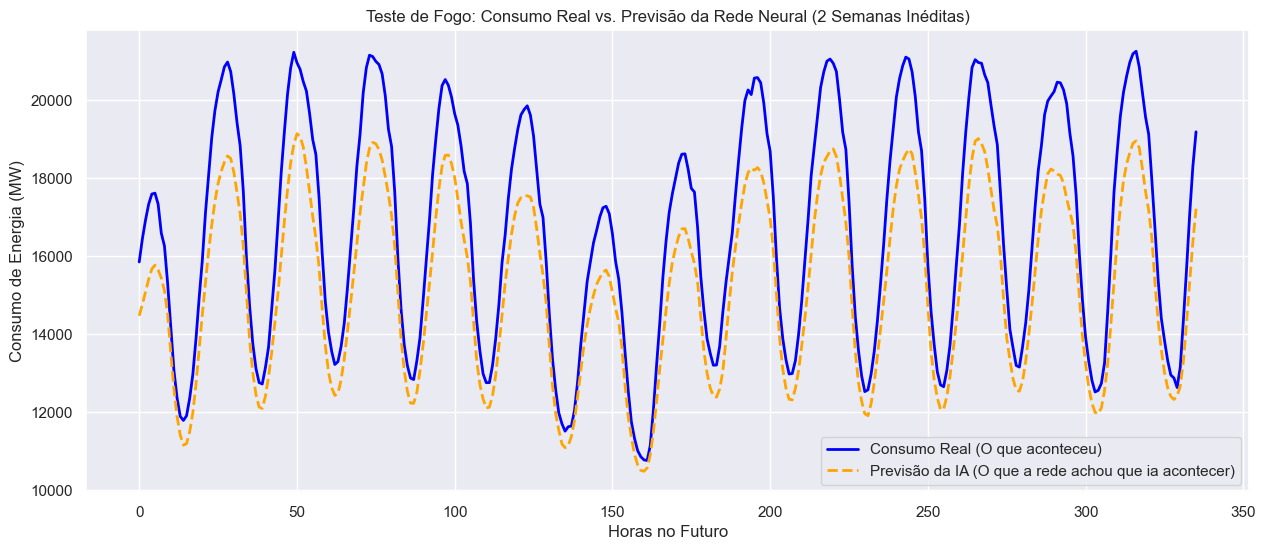

Erro Absoluto Médio (MAE): A rede está errando, em média, 1037.78 Megawatts por hora.


In [20]:
# 1. Colocar o modelo em modo de avaliação (desliga o Dropout)
modelo_mlp.eval()

# 2. Pedir para a rede fazer as previsões (sem calcular gradientes para economizar RAM)
with torch.no_grad():
    # Passamos o conjunto de teste para a GPU (se necessário) e fazemos a previsão
    previsoes_teste = modelo_mlp(X_teste_t)

# 3. Trazer os resultados de volta para o Numpy
previsoes_np = previsoes_teste.numpy()
y_teste_np = y_teste_t.numpy()

# 4. Reverter a escala de 0 a 1 de volta para Megawatts originais
previsoes_mw = scaler.inverse_transform(previsoes_np)
y_teste_mw = scaler.inverse_transform(y_teste_np)

# 5. Plotar o resultado!
# Vamos dar um "zoom" e olhar os primeiros 14 dias (336 horas) do conjunto de teste 
# para conseguirmos ver as curvas com clareza.
amostra = 24 * 14 

plt.figure(figsize=(15, 6))
plt.plot(y_teste_mw[:amostra], label='Consumo Real (O que aconteceu)', color='blue', linewidth=2)
plt.plot(previsoes_mw[:amostra], label='Previsão da IA (O que a rede achou que ia acontecer)', color='orange', linestyle='dashed', linewidth=2)

plt.title('Teste de Fogo: Consumo Real vs. Previsão da Rede Neural (2 Semanas Inéditas)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

# Calcular métrica de erro (MAE - Erro Absoluto Médio)
from sklearn.metrics import mean_absolute_error
erro_mae = mean_absolute_error(y_teste_mw, previsoes_mw)
print(f"Erro Absoluto Médio (MAE): A rede está errando, em média, {erro_mae:.2f} Megawatts por hora.")

In [21]:
# --- 1. ARQUITETURA DA CNN 1D ---

class PrevisorEnergiaCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # Extrator de Características Temporais
        self.conv_layers = nn.Sequential(
            # kernel_size=24: O filtro "lê" 1 dia inteiro por vez
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=24), 
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            # kernel_size=12: O filtro "lê" meio dia de padrões mais refinados
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=12), 
            nn.ReLU(),
            
            # Puxa a média de tudo que sobrou, independentemente do tamanho
            nn.AdaptiveAvgPool1d(1) 
        )
        
        # Classificador Final (igual ao MLP, mas menor)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        # MÁGICA: Transforma [Batch, 720] em [Batch, 1, 720] para a CNN entender
        x = x.unsqueeze(1) 
        
        features = self.conv_layers(x)
        saida = self.fc(features)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [22]:
# --- 2. TREINAMENTO ---

modelo_cnn = PrevisorEnergiaCNN()
print("Iniciando Treinamento da CNN 1D...")

# Early stopping (usando o mesmo padrão do MLP)
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer_cnn = Trainer(
    callbacks=[early_stopping_cnn], 
    max_epochs=100, 
    logger=False,
    accelerator="gpu", # Garantindo o uso da GTX 1650
    devices=1
)

trainer_cnn.fit(modelo_cnn, loader_treino, loader_val)
print("Treinamento concluído!")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\biridhin\Downloads\archive\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | conv_layers | Sequential | 25.4 K | train | 0    
1 | fc          | Sequential | 2.1 K  | train | 0    
-----------------------------------------------------------
27.6 K    Trainable params
0         Non-trainable params
27.6 K    Total params
0.110     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval

Iniciando Treinamento da CNN 1D...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


Avaliando o modelo CNN...


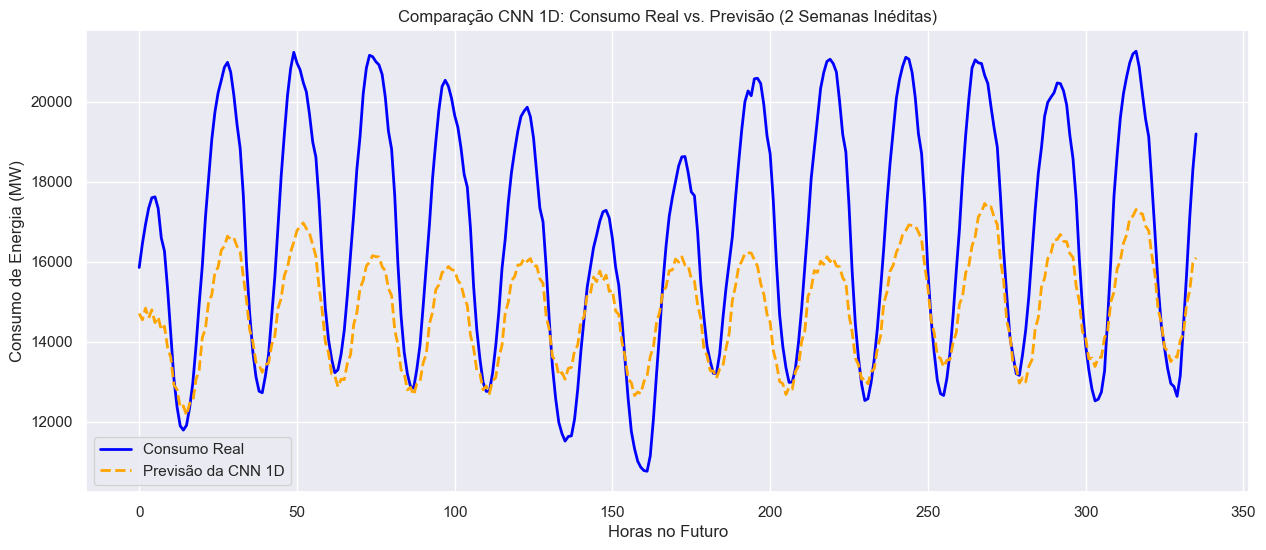

Erro Absoluto Médio (MAE) da CNN: 1347.11 MW por hora.


In [23]:
# --- 3. AVALIAÇÃO IMEDIATA ---
print("Avaliando o modelo CNN...")
modelo_cnn.cpu() # Evitar travamentos
modelo_cnn.eval()

with torch.no_grad():
    previsoes_teste_cnn = modelo_cnn(X_teste_t)

previsoes_mw_cnn = scaler.inverse_transform(previsoes_teste_cnn.numpy())

# Definir o tamanho da amostra para o gráfico (2 semanas = 14 dias * 24 horas)
amostra = 24 * 14 

plt.figure(figsize=(15, 6))

# Plotando a linha do consumo real (em azul)
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='blue', linewidth=2)

# Plotando a linha da previsão da CNN (em laranja e tracejada)
plt.plot(previsoes_mw_cnn[:amostra], label='Previsão da CNN 1D', color='orange', linestyle='dashed', linewidth=2)

# Configurações visuais do gráfico
plt.title('Comparação CNN 1D: Consumo Real vs. Previsão (2 Semanas Inéditas)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

erro_mae_cnn = mean_absolute_error(y_teste_mw, previsoes_mw_cnn)
print(f"Erro Absoluto Médio (MAE) da CNN: {erro_mae_cnn:.2f} MW por hora.")

In [24]:
# --- 1. ARQUITETURA DA REDE LSTM ---

class PrevisorEnergiaLSTM(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # input_size=1: Temos apenas 1 variável por passo no tempo (Megawatts)
        # hidden_size=64: O "tamanho do cérebro/memória" interno da rede
        # batch_first=True: Avisa que a nossa matriz X começa com o lote (Batch)
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        
        # Classificador Final
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        # Transforma [Batch, 720] em [Batch, 720, 1] para a LSTM
        x = x.unsqueeze(-1)
        
        # A LSTM retorna as saídas de todos os passos e o estado da memória (hn, cn)
        saida_lstm, (hn, cn) = self.lstm(x)
        
        # Para prever o futuro, só nos importa o que a rede pensou no ÚLTIMO passo de tempo
        # saida_lstm[:, -1, :] pega todos os lotes, o último elemento do tempo, e todas as features
        ultimo_passo = saida_lstm[:, -1, :]
        
        saida = self.fc(ultimo_passo)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [25]:
# --- 2. TREINAMENTO ---

modelo_lstm = PrevisorEnergiaLSTM()
print("Iniciando Treinamento da LSTM...")

# Early stopping 
early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer_lstm = Trainer(
    callbacks=[early_stopping_lstm], 
    max_epochs=100, 
    logger=False,
    accelerator="gpu", 
    devices=1
)

trainer_lstm.fit(modelo_lstm, loader_treino, loader_val)
print("Treinamento concluído!")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Iniciando Treinamento da LSTM...


c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\biridhin\Downloads\archive\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | lstm | LSTM       | 50.4 K | train | 0    
1 | fc   | Sequential | 2.1 K  | train | 0    
----------------------------------------------------
52.5 K    Trainable params
0         Non-trainable params
52.5 K    Total params
0.210     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [30]:
# --- 3. AVALIAÇÃO EM LOTES (Evitando o estouro de memória) ---
print("Avaliando o modelo LSTM em lotes...")
modelo_lstm.cpu()
modelo_lstm.eval()

previsoes_lista = []

with torch.no_grad():
    # Vamos passar pelo loader_teste, que entrega 64 exemplos por vez
    for x_lote, _ in loader_teste:
        saida_lote = modelo_lstm(x_lote)
        previsoes_lista.append(saida_lote)

# Junta todos os pequenos blocos de 64 de volta em um único vetor gigante
previsoes_teste_lstm = torch.cat(previsoes_lista, dim=0)

# Reverte a escala para Megawatts
previsoes_mw_lstm = scaler.inverse_transform(previsoes_teste_lstm.numpy())

erro_mae_lstm = mean_absolute_error(y_teste_mw, previsoes_mw_lstm)
print(f"Erro Absoluto Médio (MAE) da LSTM: {erro_mae_lstm:.2f} MW por hora.")



Avaliando o modelo LSTM em lotes...
Erro Absoluto Médio (MAE) da LSTM: 134.82 MW por hora.


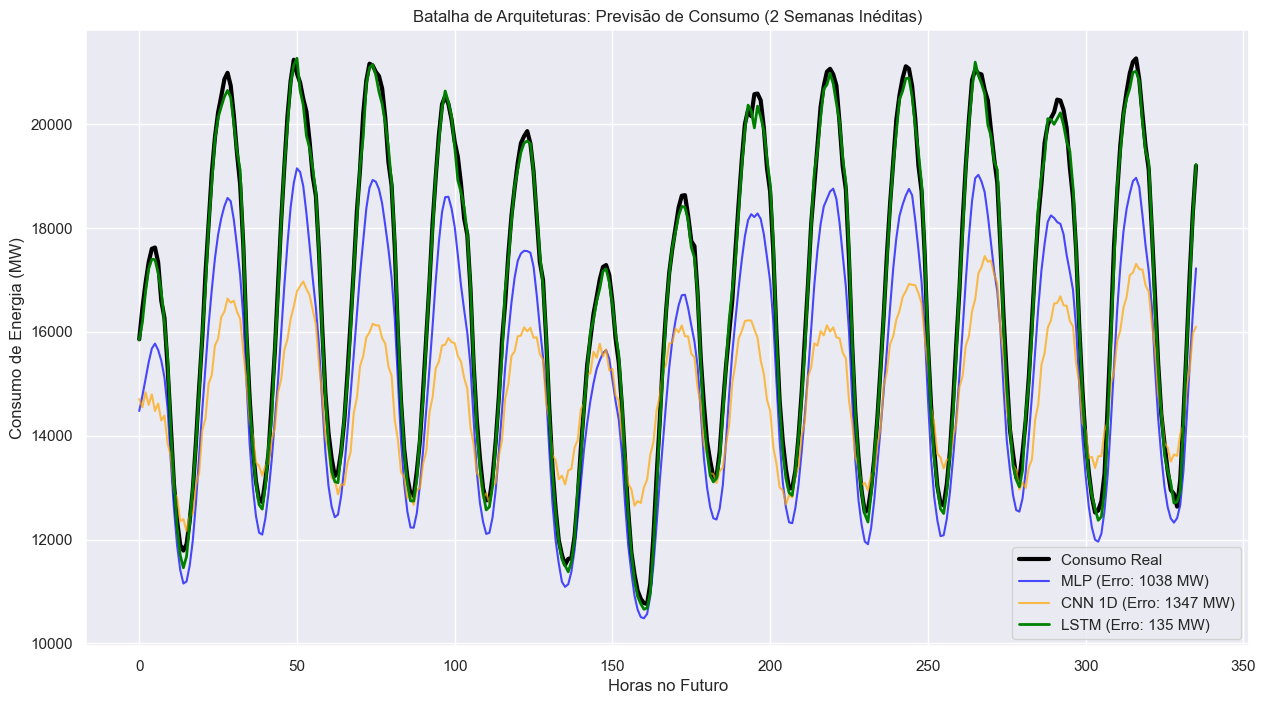

In [31]:
# --- 4. PLOT FINAL DAS 3 REDES ---
amostra = 24 * 14 # Zoom de 2 semanas

plt.figure(figsize=(15, 8))
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='black', linewidth=3)
plt.plot(previsoes_mw[:amostra], label=f'MLP (Erro: {erro_mae:.0f} MW)', color='blue', alpha=0.7)
plt.plot(previsoes_mw_cnn[:amostra], label=f'CNN 1D (Erro: {erro_mae_cnn:.0f} MW)', color='orange', alpha=0.7)
plt.plot(previsoes_mw_lstm[:amostra], label=f'LSTM (Erro: {erro_mae_lstm:.0f} MW)', color='green', linewidth=2)

plt.title('Batalha de Arquiteturas: Previsão de Consumo (2 Semanas Inéditas)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

In [32]:
# --- 1. ARQUITETURA DA CNN 1D (SEM POOLING) ---

class PrevisorCNNForcaBruta(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # Extrator de Características (Apenas Convoluções pularam o Pooling)
        self.conv_layers = nn.Sequential(
            # Entra 720, sai 697
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=24), 
            nn.ReLU(),
            
            # Entra 697, sai 686
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=12), 
            nn.ReLU()
        )
        
        # Classificador Final (Agora ele precisa engolir 43.904 conexões)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 686, 32), # A grande mudança está aqui!
            nn.ReLU(),
            nn.Dropout(0.3), # Aumentei o Dropout levemente para evitar overfitting
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        x = x.unsqueeze(1) 
        features = self.conv_layers(x)
        saida = self.fc(features)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)




In [34]:
# --- 2. TREINAMENTO ---
modelo_cnn_bruta = PrevisorCNNForcaBruta()
print("Iniciando Treinamento da CNN (Força Bruta sem Pooling)...")

early_stopping_bruta = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer_bruta = Trainer(
    callbacks=[early_stopping_bruta], 
    max_epochs=100, 
    logger=False,
    accelerator="gpu", 
    devices=1
)

trainer_bruta.fit(modelo_cnn_bruta, loader_treino, loader_val)
print("Treinamento concluído!")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | conv_layers | Sequential | 25.4 K | train | 0    
1 | fc          | Sequential | 1.4 M  | train | 0    
-----------------------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.722     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Iniciando Treinamento da CNN (Força Bruta sem Pooling)...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [35]:
# --- 3. AVALIAÇÃO ---
modelo_cnn_bruta.cpu()
modelo_cnn_bruta.eval()

with torch.no_grad():
    previsoes_teste_bruta = modelo_cnn_bruta(X_teste_t)

previsoes_mw_bruta = scaler.inverse_transform(previsoes_teste_bruta.numpy())

erro_mae_bruta = mean_absolute_error(y_teste_mw, previsoes_mw_bruta)
print(f"\nResultado da Batalha:")
print(f"Erro CNN original (com pooling): 1347.11 MW")
print(f"Erro CNN Força Bruta (sem pooling): {erro_mae_bruta:.2f} MW")


Resultado da Batalha:
Erro CNN original (com pooling): 1347.11 MW
Erro CNN Força Bruta (sem pooling): 793.97 MW


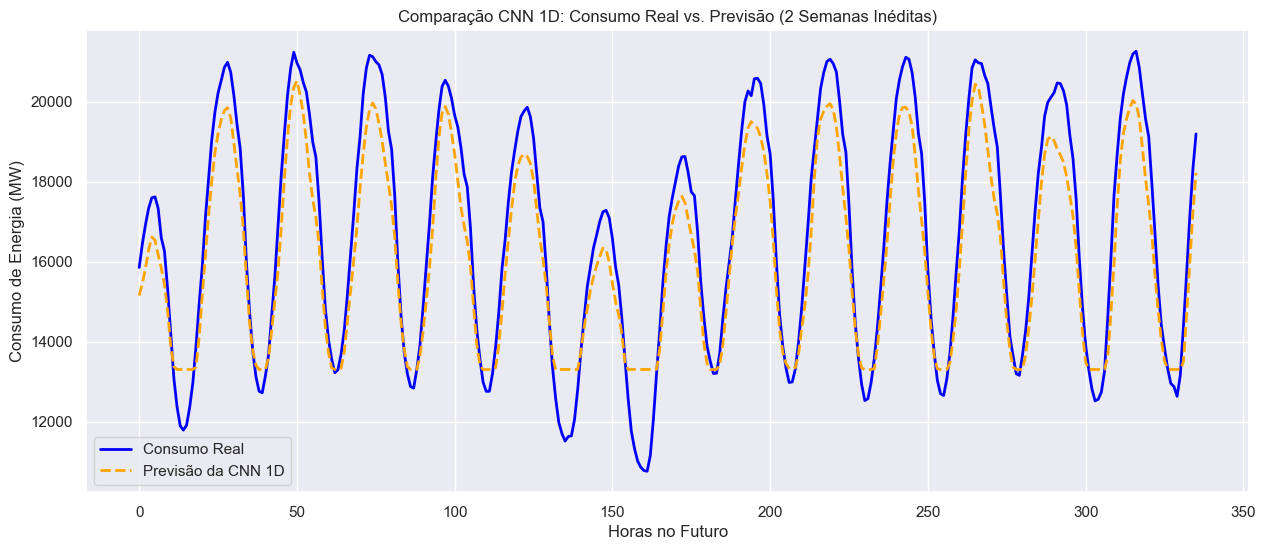

In [36]:
# Definir o tamanho da amostra para o gráfico (2 semanas = 14 dias * 24 horas)
amostra = 24 * 14 

plt.figure(figsize=(15, 6))

# Plotando a linha do consumo real (em azul)
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='blue', linewidth=2)

# Plotando a linha da previsão da CNN (em laranja e tracejada)
plt.plot(previsoes_mw_bruta[:amostra], label='Previsão da CNN 1D', color='orange', linestyle='dashed', linewidth=2)

# Configurações visuais do gráfico
plt.title('Comparação CNN 1D: Consumo Real vs. Previsão (2 Semanas Inéditas)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

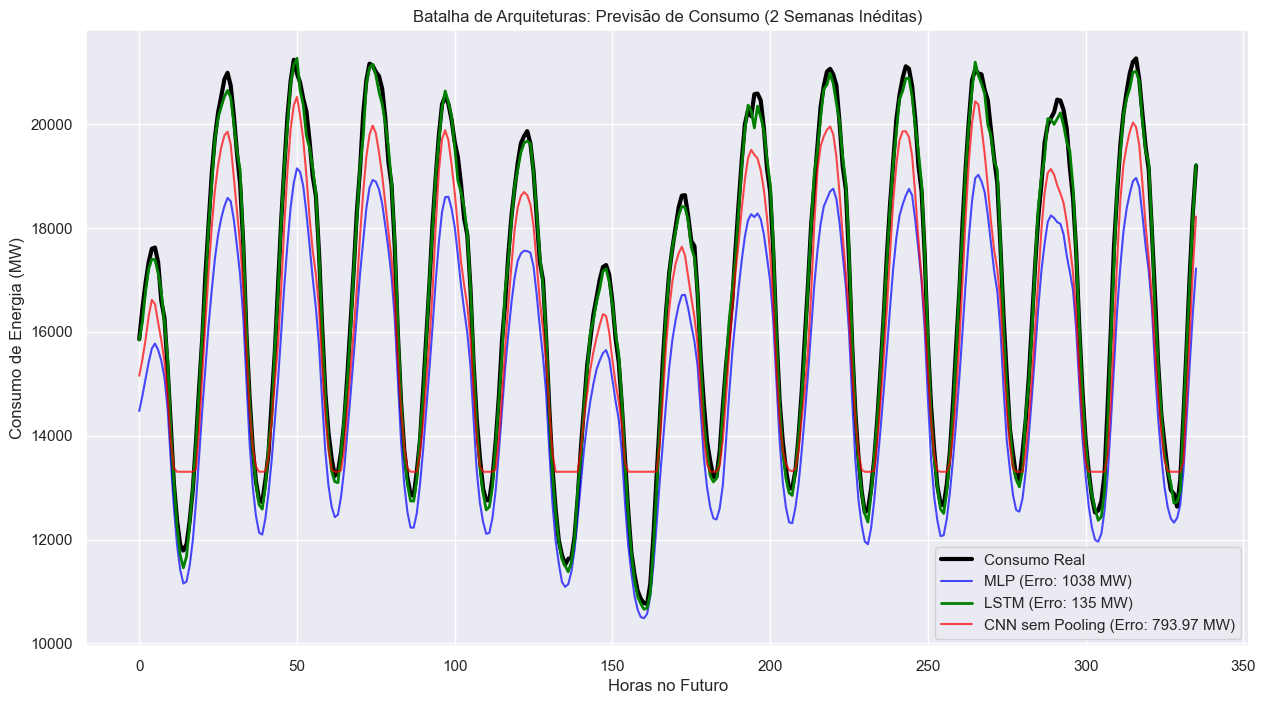

In [40]:
# --- 4. PLOT FINAL DAS 3 REDES ---
amostra = 24 * 14 # Zoom de 2 semanas

plt.figure(figsize=(15, 8))
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='black', linewidth=3)
plt.plot(previsoes_mw[:amostra], label=f'MLP (Erro: {erro_mae:.0f} MW)', color='blue', alpha=0.7)
#plt.plot(previsoes_mw_cnn[:amostra], label=f'CNN 1D (Erro: {erro_mae_cnn:.0f} MW)', color='orange', alpha=0.7)
plt.plot(previsoes_mw_lstm[:amostra], label=f'LSTM (Erro: {erro_mae_lstm:.0f} MW)', color='green', linewidth=2)
plt.plot(previsoes_mw_bruta[:amostra], label=f'CNN sem Pooling (Erro: {erro_mae_bruta:.2f} MW)', color='red', alpha=0.7)

plt.title('Batalha de Arquiteturas: Previsão de Consumo (2 Semanas Inéditas)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.show()

In [41]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning import Trainer
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- 1. ARQUITETURA HÍBRIDA (CNN + LSTM) ---

class PrevisorEnergiaHibrido(pl.LightningModule):
    def __init__(self):
        super().__init__()
        
        # 1. Extrator de Características Espaciais (CNN)
        # O filtro de 24 horas vai ler o dia e o MaxPool vai resumir a informação
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=24),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2) 
        )
        
        # 2. Processador Temporal (LSTM)
        # A CNN extrai 32 canais de características. A LSTM vai ler essa sequência.
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, num_layers=2, batch_first=True, dropout=0.2)
        
        # 3. Classificador Final
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        self.lr = 1e-3

    def forward(self, x):
        # Ajusta a dimensão para a CNN: [Lote, Canais=1, Tempo=720]
        x = x.unsqueeze(1)
        
        # A CNN mastiga os dados e cospe: [Lote, 32 Canais, Tempo Reduzido]
        features_cnn = self.cnn(x) 
        
        # A LSTM exige que o tempo venha antes dos canais: [Lote, Tempo Reduzido, 32 Canais]
        # Usamos o permute para trocar a dimensão 1 com a 2
        features_lstm = features_cnn.permute(0, 2, 1)
        
        # A LSTM processa a sequência temporal
        saida_lstm, (hn, cn) = self.lstm(features_lstm)
        
        # Pegamos o pensamento final da rede (o último passo temporal)
        ultimo_passo = saida_lstm[:, -1, :]
        
        # Passamos pela camada densa final para obter o valor em Megawatts
        saida = self.fc(ultimo_passo)
        return saida

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = nn.functional.mse_loss(self(x), y)
        self.log("val_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)



In [42]:
# --- 2. TREINAMENTO ---

modelo_hibrido = PrevisorEnergiaHibrido()
print("Iniciando Treinamento do Modelo Híbrido (CNN + LSTM)...")

early_stopping_hibrido = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer_hibrido = Trainer(
    callbacks=[early_stopping_hibrido], 
    max_epochs=100, 
    logger=False,
    accelerator="gpu", 
    devices=1
)

trainer_hibrido.fit(modelo_hibrido, loader_treino, loader_val)
print("Treinamento concluído!")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\biridhin\Downloads\archive\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | cnn  | Sequential | 800    | train | 0    
1 | lstm | LSTM       | 58.4 K | train | 0    
2 | fc   | Sequential | 2.1 K  | train | 0    
----------------------------------------------------
61.3 K    Trainable params
0         Non-trainable params
61.3 K    Total params
0.245     Total estimated model params size (MB)
9         Modules in train mode
0         Mod

Iniciando Treinamento do Modelo Híbrido (CNN + LSTM)...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\biridhin\miniconda3\envs\d2l\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Treinamento concluído!


In [43]:
# --- 3. AVALIAÇÃO EM LOTES (Para não estourar a memória) ---

print("Avaliando o modelo Híbrido em lotes...")
modelo_hibrido.cpu()
modelo_hibrido.eval()

previsoes_lista_hibrido = []

with torch.no_grad():
    for x_lote, _ in loader_teste:
        saida_lote = modelo_hibrido(x_lote)
        previsoes_lista_hibrido.append(saida_lote)

previsoes_teste_hibrido = torch.cat(previsoes_lista_hibrido, dim=0)

# Revertendo a escala
previsoes_mw_hibrido = scaler.inverse_transform(previsoes_teste_hibrido.numpy())

erro_mae_hibrido = mean_absolute_error(y_teste_mw, previsoes_mw_hibrido)
print(f"\n---> Erro Absoluto Médio (MAE) do HÍBRIDO: {erro_mae_hibrido:.2f} MW por hora <---")

Avaliando o modelo Híbrido em lotes...

---> Erro Absoluto Médio (MAE) do HÍBRIDO: 170.11 MW por hora <---


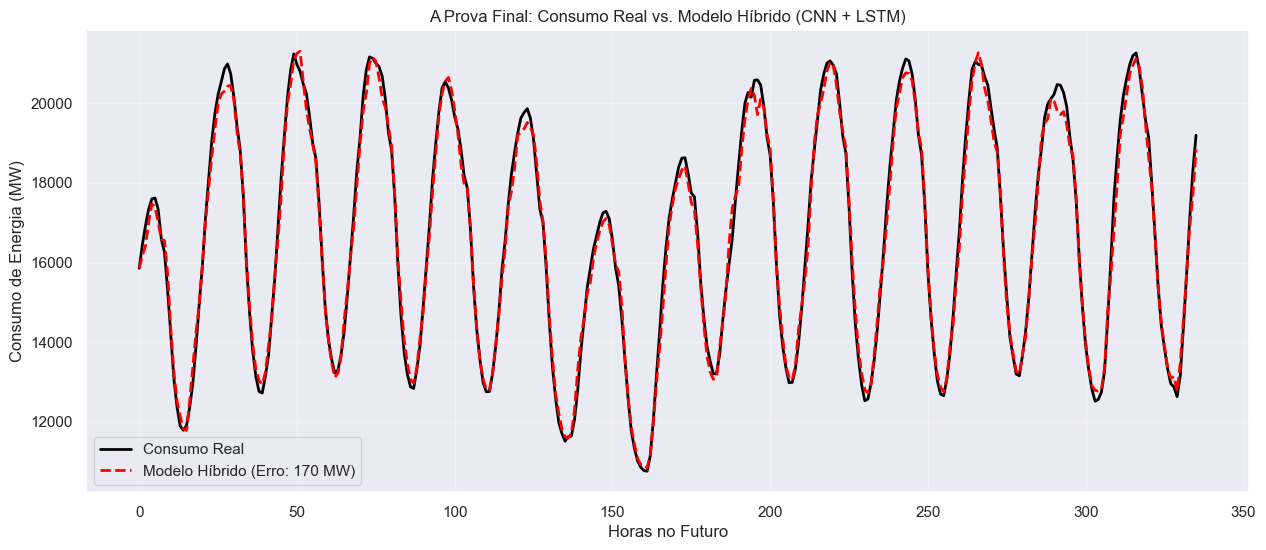

In [44]:
# --- 4. PLOT FINAL: CONSUMO REAL VS HÍBRIDO ---

amostra = 24 * 14 # Analisando um período de 2 semanas

plt.figure(figsize=(15, 6))
plt.plot(y_teste_mw[:amostra], label='Consumo Real', color='black', linewidth=2)
plt.plot(previsoes_mw_hibrido[:amostra], label=f'Modelo Híbrido (Erro: {erro_mae_hibrido:.0f} MW)', color='red', linestyle='dashed', linewidth=2)

plt.title('A Prova Final: Consumo Real vs. Modelo Híbrido (CNN + LSTM)')
plt.xlabel('Horas no Futuro')
plt.ylabel('Consumo de Energia (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()